# Treatment and the four modes of therapeutic escape

A tumour that relapses under therapy did so for one of a small number of reasons, and which one
matters clinically: only some are preventable by changing the course. [Kane et
al. (2026)](https://doi.org/10.64898/2025.12.29.696883) organise this into **four modes of clonal
expansion under treatment**, and this notebook reproduces all four in `iscc`.

|   | tumour responds? | where the relapsing lineage came from |
|---|---|---|
| **I**  | no  | resistance is common and cost-free — the deposit already carries it |
| **II** | no  | resistance is advantageous and swept to fixation *before* therapy |
| **III**| yes | a rare pre-existing clone, present at the first dose, expands under it |
| **IV** | yes | no resistant cell existed at the first dose — resistance arose **on drug** |

I and II are *primary* resistance: the tumour never responds. III and IV are *acquired*: it regresses
and then relapses, and they differ **only** in whether the relapsing lineage predates treatment. That
is the distinction bulk sequencing at relapse cannot make — the relapsed tumour looks resistant either
way — and it is the one `iscc` knows by construction, because it records which cell first acquired
resistance.

**Only the genetics differ between the panels.** Every mode below is dosed with the same kill model
(`kill_mode="proliferation"`, `kill_rate=1.0`), the same 120-generation course and the same
90-generation drug-free tail. What changes is how frequent resistance is in the founding population
and what it costs.

This notebook **loads pre-computed runs** — each panel grows a tumour to ~85,000 cells and takes
several minutes. Regenerate them with:

```
python validation/validate_escape_modes.py
```

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt

CACHE = os.path.join("..", "validation", ".cache_escape_modes")
MODES = [
    ("I",   "resistance common and free",        "no response"),
    ("II",  "resistance advantageous, sweeps",   "no response"),
    ("III", "rare pre-existing clone",           "responds, relapses from that clone"),
    ("IV",  "de novo under therapy",             "responds, relapses from a lineage born on drug"),
]

if not os.path.isdir(CACHE):
    raise SystemExit(f"no cached runs at {CACHE}\n"
                     f"  generate them first:  python validation/validate_escape_modes.py")

runs = {}
for key, _, _ in MODES:
    z = np.load(os.path.join(CACHE, f"{key}.npz"), allow_pickle=True)
    runs[key] = {k: z[k] for k in z.files}

print(f"{'mode':<5}{'cells at 1st dose':>18}{'resistant':>11}{'response':>10}"
      f"{'relapse':>10}{'% resistant':>13}")
for key, _, _ in MODES:
    r = runs[key]
    s, res = r["sens"].astype(float), r["res"].astype(float)
    c0, c1 = int(r["c0"]), int(r["c1"])
    burden = (s + res)[c0:c1 + 1]
    depth = burden[0] / max(burden.min(), 1.0)      # burden at the first dose / nadir
    tot = max(s[-1] + res[-1], 1)
    print(f"{key:<5}{int(s[c0] + res[c0]):>18,}{int(res[c0]):>11,}{depth:>9.1f}x"
          f"{int(tot):>10,}{100 * res[-1] / tot:>12.2f}%")

mode  cells at 1st dose  resistant  response   relapse  % resistant
I                 2,297      2,297      1.0x    87,591      100.00%
II                2,660      2,594      1.0x    86,364      100.00%
III               2,250         33     11.7x    87,174       99.68%
IV                3,518          0     39.5x    86,117      100.00%


## The four modes

Each panel is the metastatic deposit through treatment: **blue** sensitive cells, **red** resistant,
the shaded band the dosing course, and time measured from the first dose.

Read the left edge of the band first — that is what separates primary from acquired resistance. In
I and II the deposit is already red when dosing starts. In III a thin red sliver is present. In IV
there is none at all, and the red appears *inside* the band.

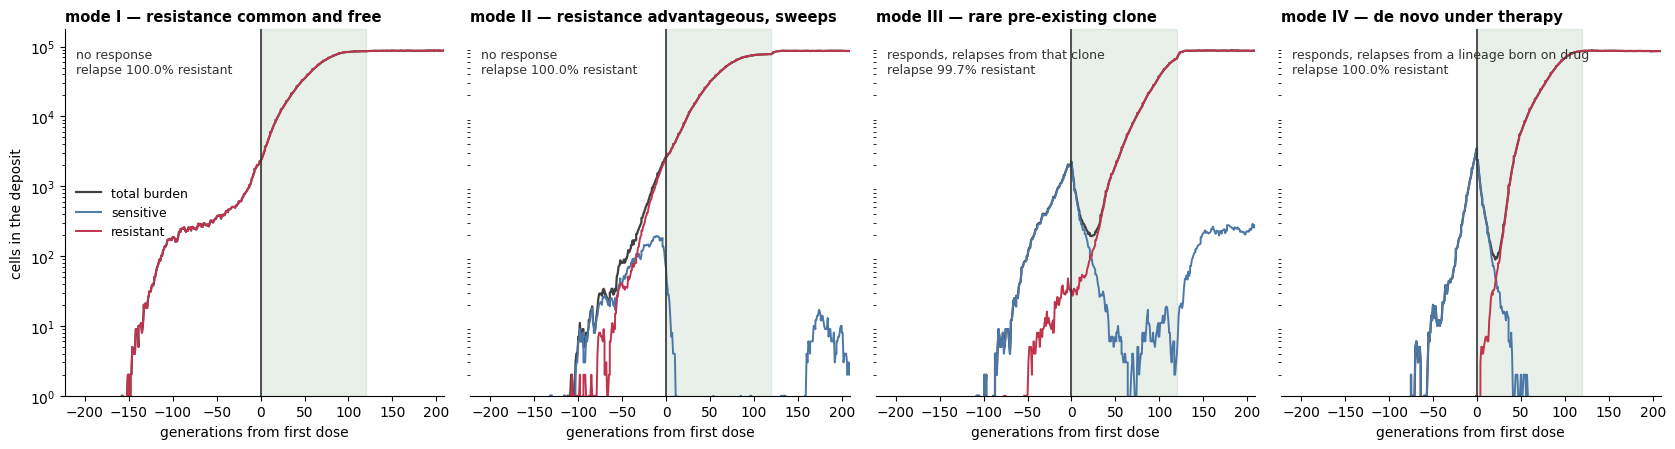

In [2]:
SENS, RES, BAND = "#4c78a8", "#c1344e", "#2f6d3a"
# ONE shared, LOG y-axis across the four panels. Two separate problems needed fixing. Letting each
# panel autoscale made a deposit ten times larger look identical to a small one. But a shared LINEAR
# axis was worse: the deposit regrows to ~9e4 cells, which dwarfs the response, so all four panels
# collapsed to the same shape and the nadir vanished. Tumour burden is conventionally plotted on a
# log axis precisely because response and regrowth differ by orders of magnitude, and on it the
# modes separate: I and II never dip, III and IV fall and then climb back.
fig, axes = plt.subplots(1, 4, figsize=(17, 4.6), sharey=True)
ymax = max(float((runs[k]["sens"].astype(float) + runs[k]["res"].astype(float)).max())
           for k, _, _ in MODES)

for ax, (key, genetics, verdict) in zip(axes, MODES):
    r = runs[key]
    s, res = r["sens"].astype(float), r["res"].astype(float)
    c0, c1 = int(r["c0"]), int(r["c1"])
    g = r["trace_gen"].astype(float)
    x = g - g[c0]                                  # generations relative to the first dose
    ax.axvspan(x[c0], x[c1], color=BAND, alpha=0.10, zorder=0)
    # Lines, not a stackplot: a filled stack cannot be read on a log axis (its baseline is 0).
    ax.plot(x, np.maximum(s + res, 1e-9), color="0.25", lw=1.6, label="total burden")
    ax.plot(x, np.maximum(s, 1e-9), color=SENS, lw=1.4, label="sensitive")
    ax.plot(x, np.maximum(res, 1e-9), color=RES, lw=1.4, label="resistant")
    ax.axvline(0, color="0.2", lw=1.2)
    ax.set_xlim(x[max(c0 - 260, 0)], x[-1])
    ax.set_yscale("log"); ax.set_ylim(1, ymax * 2)
    ax.set_title(f"mode {key} — {genetics}", loc="left", fontsize=10.5, fontweight="bold")
    tot = max(s[-1] + res[-1], 1)
    ax.text(0.03, 0.95, f"{verdict}\nrelapse {100 * res[-1] / tot:.1f}% resistant",
            transform=ax.transAxes, va="top", fontsize=9, color="0.2")
    ax.set_xlabel("generations from first dose")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("cells in the deposit")
for ax in axes[1:]:
    ax.spines["left"].set_visible(False); ax.tick_params(left=False)
axes[0].legend(loc="center left", fontsize=9, frameon=False)
fig.tight_layout()

## Two things worth knowing before reusing this

**Mode IV is stochastic by construction.** It needs a metastatic deposit founded *without* resistance
**and** a de novo lineage that establishes rather than drifting out. The metastatic bottleneck makes
standing resistance in the deposit bimodal rather than smoothly Poisson — either a founder carried it
or none did — so roughly one seed in six yields the mode. The panel above is a selected seed, and any
figure of this kind should say so.

**Mode IV alone is dosed with a mutagenic drug, and that asymmetry is forced.** Since III and IV differ
only in where the relapsing lineage came from, a drug mutagenic enough to manufacture IV's de novo
clone also manufactures one in III, where it outcompetes the pre-existing clone that defines the mode.
Measured: under the same mutagen, mode III falls below its own response threshold and relapses from a
de novo lineage. **No single drug produces all four modes** — that is a property of the definitions,
not a tuning failure.

See `validation/validate_escape_modes.py` for the acceptance criteria each panel is checked against,
and the manuscript section "reproduces the four modes of therapeutic escape".